In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('../polygraphpy/data/original_dataset.csv')
inchi_list = df['inchi'].drop_duplicates().values

scaler = MinMaxScaler()
xlogp_list = scaler.fit_transform(df['xlogp'].values.reshape(-1,1)).flatten()

In [2]:
inchi_list[0]

'InChI=1S/C3H4O2/c1-2-3(4)5/h2H,1H2,(H,4,5)'

In [3]:
xlogp_list[0]

np.float64(0.2190082644628099)

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch
import rdkit.Chem as Chem

# Data
texts = [f"xlogp: {p} InChI: {i}" for i, p in zip(inchi_list, xlogp_list)]

tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
model = AutoModelForCausalLM.from_pretrained('gpt2')
model.resize_token_embeddings(len(tokenizer))

class InChIDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len, return_tensors='pt')

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

dataset = InChIDataset(texts, tokenizer)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)

# Training
model.train()
for epoch in range(25):
    epoch_loss = 0.0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch, labels=batch['input_ids'])
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch['input_ids'].size(0)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss / len(dataset):.4f}")

/home/jgduarte/Documents/RA/Projects/3M/PolyGraphPy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Epoch 1, Loss: 0.8528
Epoch 2, Loss: 0.5776
Epoch 3, Loss: 0.5047
Epoch 4, Loss: 0.4601
Epoch 5, Loss: 0.4284
Epoch 6, Loss: 0.4028
Epoch 7, Loss: 0.3815
Epoch 8, Loss: 0.3628
Epoch 9, Loss: 0.3469
Epoch 10, Loss: 0.3319
Epoch 11, Loss: 0.3189
Epoch 12, Loss: 0.3060
Epoch 13, Loss: 0.2944
Epoch 14, Loss: 0.2832
Epoch 15, Loss: 0.2724
Epoch 16, Loss: 0.2629
Epoch 17, Loss: 0.2539
Epoch 18, Loss: 0.2451
Epoch 19, Loss: 0.2368
Epoch 20, Loss: 0.2284
Epoch 21, Loss: 0.2215
Epoch 22, Loss: 0.2143
Epoch 23, Loss: 0.2075
Epoch 24, Loss: 0.2011
Epoch 25, Loss: 0.1956


In [14]:
torch.save(model, 'gpt2_xlogp.pt')

In [5]:
# Generation
def generate(model, tokenizer, xlogp_val, n=5, max_len=1000):
    model.eval()
    for i in range(n):
        prompt = f"xlogp: {xlogp_val} InChI:"
        inputs = tokenizer(prompt, return_tensors='pt').to(device)
        outputs = model.generate(**inputs, max_length=max_len, num_return_sequences=1, num_beams=4, early_stopping=True, top_k=50)
        gen_text = tokenizer.decode(outputs[0])
        inchi = gen_text.split("InChI:")[1].strip() if "InChI:" in gen_text else None
        inchi = inchi.split('[')[0]
        valid = inchi and Chem.MolFromInchi(inchi) is not None
        print(f"Sample {i+1}: {inchi} - Valid: {valid}")

In [6]:
generate(model, tokenizer, 0.0555)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 1: InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 2: InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 3: InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 4: InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+ - Valid: True
Sample 5: InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+ - Valid: True


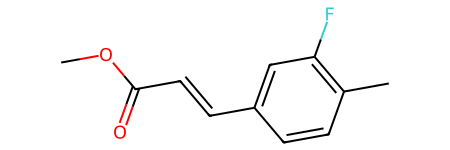

In [11]:
Chem.MolFromInchi('InChI=1S/C11H11FO2/c1-8-3-4-9(7-10(8)12)5-6-11(13)14-2/h3-7H,1-2H3/b6-5+')

In [7]:
generate(model, tokenizer, 0.6555)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 1: InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 2: InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 3: InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 4: InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+ - Valid: True
Sample 5: InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+ - Valid: True


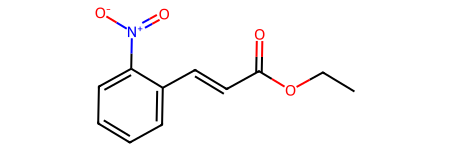

In [12]:
Chem.MolFromInchi('InChI=1S/C11H11NO4/c1-2-16-11(13)8-7-9-5-3-4-6-10(9)12(14)15/h3-8H,2H2,1H3/b8-7+')

In [8]:
generate(model, tokenizer, 1)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 1: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 2: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 3: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 4: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True
Sample 5: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


In [9]:
generate(model, tokenizer, 0.2190082644628099)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 1: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 2: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 3: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Sample 4: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True
Sample 5: InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+ - Valid: True


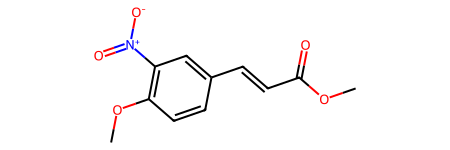

In [10]:
Chem.MolFromInchi('InChI=1S/C11H11NO5/c1-16-10-5-3-8(4-6-11(13)17-2)7-9(10)12(14)15/h3-7H,1-2H3/b6-4+')